Here we will demonstrate how to setup the $\texttt{RateCalculator}$ for computing the expected number of subhalo impacts under different dark matter models. 

We will highlight one minor improvement over previous work. 

Suppose the subhalos follow an isotropic Maxwellian. In this case, one can show that the imact time distribution is proportional to the product of the stream's length times the local subhalo number density. Previous works assume only the length factor. Below, we show that the default behavior is to only use the stream's length in sampling impact times. However, one can also pass in an array of the local subhalo number density along the progenitor's orbit and a series of corresponding times. Under the hood, the impact generator will use both factors to sample impact times.

In [14]:
from astropy import units as u
from streamsculptor.main import usys
import jax.numpy as jnp
from astropy.coordinates import SkyCoord, Galactocentric


import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

import streamsculptor as ssc
from streamsculptor import potential
from streamsculptor import JaxCoords as jc
import diffrax


from streamsculptor import JaxCoords as jc

import matplotlib as mpl

## Some plotting things (not necessary)
import scienceplots
plt.style.use('science')
mpl.rcParams['text.usetex'] = False ## We do not have LaTex on the HPC...



First we will define a gd-1 centric frame. These transformations are written in Jax so they can be differentiated.

In [2]:
@jax.jit
def icrs_to_gd1(ra_rad, dec_rad):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> gd1 phi1, phi2
    Using the rotation matrix from Koposov+2010
    ra_rad: icrs ra [radians]
    dec_red: icrs dec [radians]
    """
    R = jnp.array(
        [
            [-0.4776303088, -0.1738432154, 0.8611897727],
            [0.510844589, -0.8524449229, 0.111245042],
            [0.7147776536, 0.4930681392, 0.4959603976],
        ]
    )


    icrs_vec = jnp.vstack([jnp.cos(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(dec_rad)]).T

    stream_frame_vec = jnp.einsum('ij,kj->ki',R,icrs_vec)
    
    phi1 = jnp.arctan2(stream_frame_vec[:,1],stream_frame_vec[:,0])*180/jnp.pi
    phi2 = jnp.arcsin(stream_frame_vec[:,2])*180/jnp.pi

    
    return phi1, phi2

@jax.jit
def get_phi12_from_stream(stream):
    """
    Differentiable helper function that takes us from simulated stream --> phi1, phi2
    """
    ra_s, dec_s, dist_ = jax.vmap(jc.simcart_to_icrs)(stream[:,:3])
    phi1_model, phi2_model = icrs_to_gd1(ra_s*jnp.pi/180, dec_s*jnp.pi/180)
    return phi1_model, phi2_model


Estimated progenitor location today in [kpc, kpc, kpc, kpc/Myr, kpc/Myr, kpc/Myr]
Estimated in a seperate file, but will provide a good starting point for this notebook. This file can be found in the data folder of the streamsculptor repository:
``data/GD1_prog/GD1_progenitor.npy``

In [3]:
prog_wtoday = jnp.load('../data/GD1_prog/GD1_progenitor.npy',allow_pickle=True).item()
pos = prog_wtoday.pos.xyz.to(u.kpc).value
vel = prog_wtoday.vel.d_xyz.to(u.kpc/u.Myr).value
prog_wtoday = jnp.hstack([pos,vel])


Setup the potential, stream age, dissolution time, stripping times. Then generate an unperturbed stream:

In [4]:
## Use Gala's MW potential
pot = potential.GalaMilkyWayPotential(units=usys)
## Define the age of the stream [Myr]
t_age = 2500.0
## Past time at which it dissolved [Myr]
t_dissolve = -300.0
## Get initial conditions
IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,ts=jnp.array([-t_age])).ys[0]

In [5]:
IC

Array([ 1.78128932e+00, -2.18323743e+01,  1.80723705e+00,  1.31330126e-01,
       -1.13414892e-02, -1.14419502e-01], dtype=float64)

In [6]:
## Define stripping times. ts[-1] is always the final integration time for gen_stream simulations
ts = jnp.hstack([jnp.linspace(-t_age,t_dissolve,2_000), jnp.array([0.0])])
## Generate unperturbed stream [l: lead, t: trail]
l ,t = pot.gen_stream_scan(prog_w0=IC,ts=ts,seed_num=532,Msat=1e4,atol=1e-6,rtol=1e-6,solver=diffrax.Dopri5())
stream = jnp.vstack([l,t])

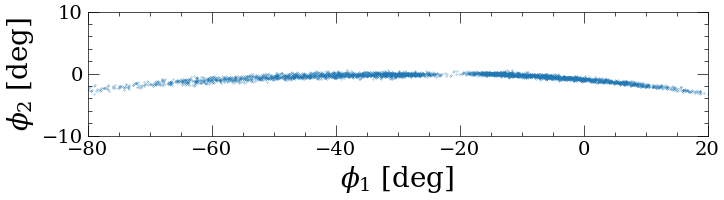

In [7]:
phi1_model, phi2_model = get_phi12_from_stream(stream)

fig, ax = plt.subplots(1,1)
fig.set_size_inches(8,8)
ax.scatter(phi1_model, phi2_model,s=.05,color='tab:blue')

    
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10,10)
ax.set_xlim(-80,20)
ax.set_xlabel(r'$\phi_1$ [deg]',fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]',fontsize=20)
ax.set_aspect('equal')

Goodbye, stream. 

Now we will introduce $N$ subhalos, using the ```ImpactGenerator```. The docstring of this function provides a decent overview, but the basic idea is that we randomly generate impacts by taking the average phase-space location of particles in $\phi_1$ bands (one such average gives us a "phase-space patch"), integrate back to an impact time, and randomly sample impact parameters, angles, and speeds in the frame of the phase-space patch we have just backwards integrated. 

We record the randomly sampled impact parameters, and a Cartesian representation of the subhalo fly-by, and output this information for use in setting up the potentials of the fly-bys. The bounds of the impact parameters (including time of impact, impact angles, distance of closest approach, etc.) can all be adjusted. Sensible defaults are provided.

Here's an example usage with 20 subhalos. Notice that for any case, the ``ImpactGenerator`` needs the unperturbed stream's $\phi_1$ coordinate to parametrize the impacts. This coordinate can be in physical units of (e.g.) length, deg, radian, etc. The only requirement is that it is some scalar parameter that is mappable to the arclength of the stream's track. 

In [36]:
from streamsculptor.GenerateImpactParams import ImpactGenerator

# note you can use custom bImpact_bounds = [jnp.zeros(20), jnp.ones(20)*.1] (for example) to have different impact parameter bounds for each impact

ImpactGen = ImpactGenerator(pot=pot, 
                            tobs=0.0, 
                            stream=stream, 
                            stream_phi1=phi1_model, 
                            phi1_bounds=[-80.,20.],
                            tImpactBounds=[-2500,0.0],
                            phi1window=.8, 
                            NumImpacts=20,
                            bImpact_bounds=[0,.1],
                            stripping_times=jnp.hstack([ts[:-1],ts[:-1]]),
                            prog_today=prog_wtoday,
                            seednum=100)

ImpactDict = ImpactGen.get_subhalo_ImpactParams()
print(ImpactDict.keys())

dict_keys(['CartesianImpactParams', 'ImpactFrameParams'])


By default, impact times are sampled from a pdf that is proportional to the stream's estimated length over time

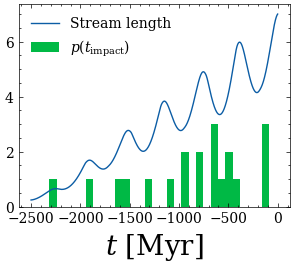

In [37]:
tImp = ImpactDict['ImpactFrameParams']['tImpact']
length_osc = ImpactGen.length_osc
plt.plot(length_osc['ts'],length_osc['length_func']/3,label='Stream length')
plt.hist(tImp,bins=30, label=r'$p(t_{\rm impact})$');
plt.xlabel(r'$t$ [Myr]',fontsize=20)

plt.legend()


For a maxwellian subhalo velocity distribution, the impact time should be sampled in proportion to the stream's length $l(t)$ times the local subhalo number density $n_{\rm sub}(r(t))$. That is, $$p(t_{\rm impact}) \propto l(t) \times n_{\rm sub}\left(r(t)\right).$$

We can pass in the subhalo number density evaluated along the progenitor's orbit from $[-t_{\rm age},0]$ to correctly samples from $p(t_{\rm impact})$. This will require us to specify a suhalo number density, from the rate calculator

In [38]:
t_age

2500.0

In [43]:
from streamsculptor.subhalostatistics import RateCalculator
tsave = jnp.linspace(-t_age,0,500)
prog_orb = pot.integrate_orbit(w0=IC, t0=-t_age, t1=0.0,ts=tsave)
l_obs = ssc.compute_stream_length(stream=stream, phi1=phi1_model)
RC = RateCalculator(orbit=prog_orb,t_age=t_age,b_max_fac=5.0, l_obs=l_obs)

r_orb = RC.orbital_r
nsub_along_orb = RC.nsub(r_orb)

## now plug this into the impactgenerator

ImpactGen_correct = ImpactGenerator(pot=pot, 
                            tobs=0.0, 
                            stream=stream, 
                            stream_phi1=phi1_model, 
                            phi1_bounds=[-80.,20.],
                            tImpactBounds=[-2500,0.0],
                            phi1window=.8, 
                            NumImpacts=20,
                            bImpact_bounds=[0,.1],
                            stripping_times=jnp.hstack([ts[:-1],ts[:-1]]),
                            prog_today=prog_wtoday,
                            nsub_times=tsave,
                            nsub_vals=nsub_along_orb,
                            seednum=100)

# now sample
ImpactDict_correct = ImpactGen_correct.get_subhalo_ImpactParams()


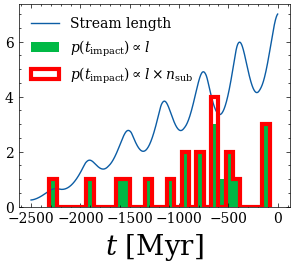

In [44]:
tImp = ImpactDict['ImpactFrameParams']['tImpact']
tImp_correct = ImpactDict_correct['ImpactFrameParams']['tImpact']
length_osc = ImpactGen.length_osc
plt.plot(length_osc['ts'],length_osc['length_func']/3,label='Stream length')
plt.hist(tImp,bins=30, label=r'$p(t_{\rm impact}) \propto l$');
plt.hist(tImp_correct,bins=30, histtype='step',color='r',lw=3,label=r'$p(t_{\rm impact}) \propto l \times n_{\rm sub}$ ');
plt.xlabel(r'$t$ [Myr]',fontsize=20)

plt.legend()
